In [1]:
import ccxt

In [6]:
ex = ccxt.kucoin()
tr = ex.fetch_ticker('BTC/USDT')
print(tr)

{'symbol': 'BTC/USDT', 'timestamp': 1789368256456, 'datetime': '2026-09-14T06:44:16.456Z', 'high': 77875.2, 'low': 76372.8, 'bid': 77723.4, 'bidVolume': None, 'ask': 77723.5, 'askVolume': None, 'vwap': 77116.1536449904, 'open': 77287.1, 'close': 77723.4, 'last': 77723.4, 'previousClose': None, 'change': 436.3, 'percentage': 0.56, 'average': 77086.37126069, 'baseVolume': 4371.194269024786, 'quoteVolume': 337089688.86221695, 'markPrice': None, 'indexPrice': None, 'info': {'time': 1789368256456, 'symbol': 'BTC-USDT', 'buy': '77723.4', 'sell': '77723.5', 'changeRate': '0.0056', 'changePrice': '436.3', 'high': '77875.2', 'low': '76372.8', 'vol': '4371.194269024786473908', 'volValue': '337089688.8622169197947539588', 'last': '77723.4', 'averagePrice': '77086.37126069', 'takerFeeRate': '0.001', 'makerFeeRate': '0.001', 'takerCoefficient': '1', 'makerCoefficient': '1'}}


In [7]:
from datetime import datetime

datetime.now().strftime("%y/%m/%d %H:%M:%S")

'26/09/13 23:59:58'

In [26]:
timeval = int(datetime.strptime("2026/09/11 21:59:30", "%Y/%m/%d %H:%M:%S").timestamp()*1000)
print(timeval)

1789189170000


In [27]:
srf = ccxt.bybit()
getprs = srf.fetch_ohlcv('BTC/USDT', '1d', since=timeval)
print(getprs)

[[1789257600000, 77285.0, 77461.5, 76501.1, 76834.4, 2650.987262], [1789344000000, 76834.4, 77895.5, 76362.0, 77851.6, 1915.268849]]


In [28]:
print(list(getprs))

[[1789257600000, 77285.0, 77461.5, 76501.1, 76834.4, 2650.987262], [1789344000000, 76834.4, 77895.5, 76362.0, 77851.6, 1915.268849]]


In [29]:
from fastapi import FastAPI

app = FastAPI()

@app.post("/")
def get_prs(prs = list):
    return {"prs" : prs}

In [18]:
from datetime import datetime
print(datetime.fromtimestamp(100200000000/1000).date())
print(datetime.now().timestamp())

1973-03-05
1789457021.652875


In [2]:
import requests

getprs = requests.get("http://194.146.123.51:8000/okx/2026-1-01")

print(getprs.status_code)

200


In [61]:
srfdt = getprs.json()['prs'][-1][0]
print(datetime.fromtimestamp(srfdt/1000).month)
print(datetime.now())

nwts = datetime.now().timestamp()

print(srfdt, nwts*1000, (int(nwts*1000) - srfdt)/1000)

4
2026-09-14 14:08:23.423455
1775865600000 1789420103423.455 13554503.423


In [33]:
print()
#2026-09-13 17:00:00           77483094.99316406
print(datetime(2026, 9, 14, 0, 0, 0).timestamp() - datetime(2026, 9, 13, 0, 0, 0).timestamp())


86400.0


In [6]:
import time

In [3]:
list1 = [[1], [2]]
list2 = [[5],[8]]

list1 = list1 + list2

print(list1)

[[1], [2], [5], [8]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


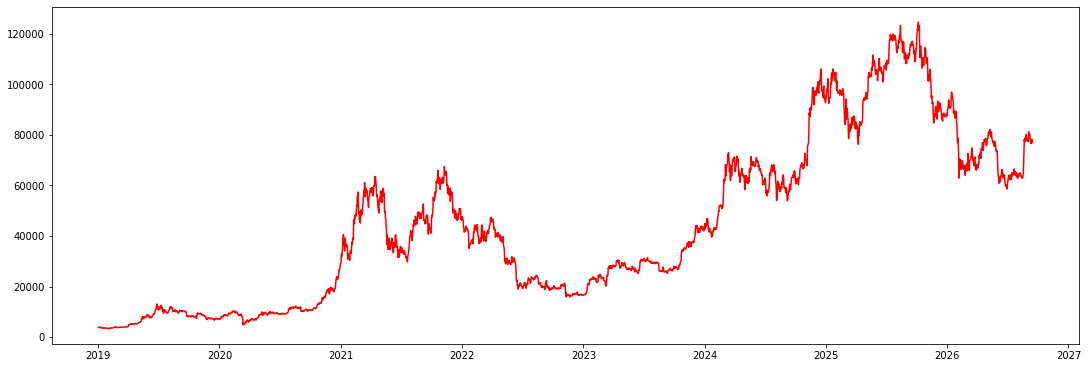

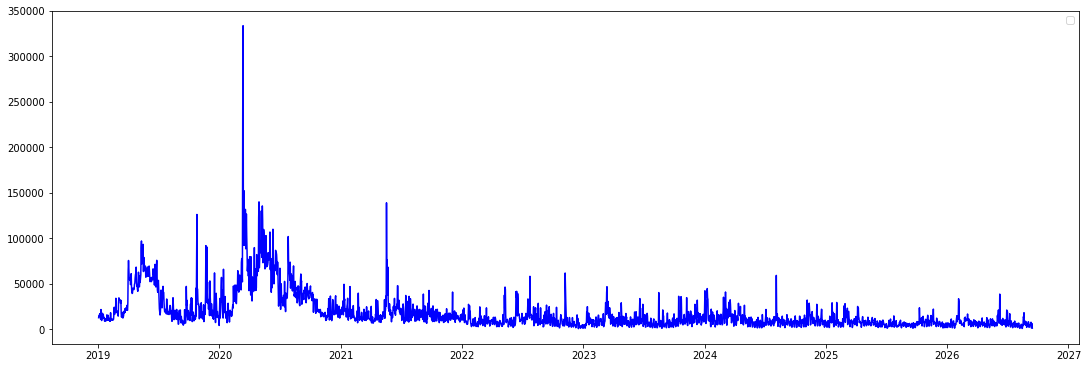

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

dtf = pd.read_csv('BTC-USDT/okx.csv')

datelist = [datetime.fromtimestamp(i/1000).date() for i in dtf['timestamp']]

plt.figure(figsize=(15, 5), layout='constrained')
plt.plot(np.array(datelist), dtf['open'].to_numpy(), 'red')

plt.figure(figsize=(15, 5), layout='constrained')
plt.plot(np.array(datelist), dtf['volume'].to_numpy(), 'blue')

plt.legend()

techincal formula for CRP

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import math

In [22]:
crpdata = pd.read_csv('BTC-USDT/okx.csv')

datex = [datetime.fromtimestamp(i/1000) for i in crpdata['timestamp']]
npdate = np.array(datex[1:])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


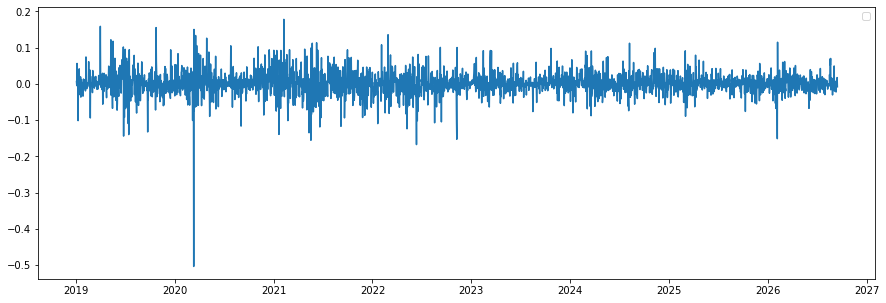

In [23]:
#log return function

lgr = np.array([math.log(crpdata['close'][i]/crpdata['close'][i-1]) for i in range(1, len(crpdata['close']))]) 

plt.figure(figsize=(15, 5))
plt.plot(npdate, lgr)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


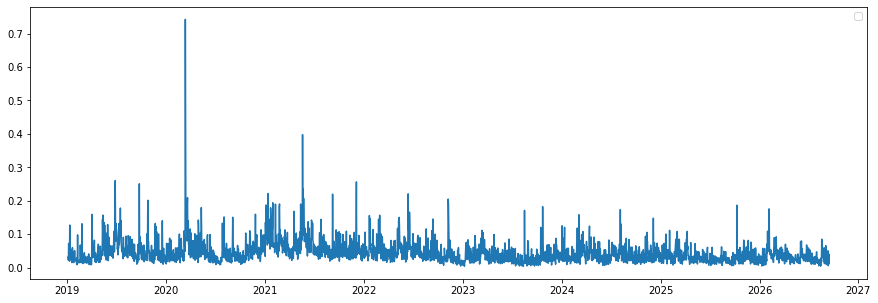

In [30]:
#volatility Function 

vlt = np.array((crpdata['high'][1:]-crpdata['low'][1:])/crpdata['close'][1:])

plt.figure(figsize=(15,5))
plt.plot(npdate, vlt)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


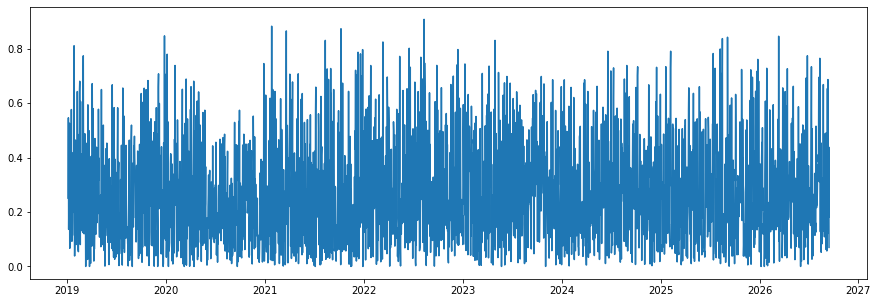

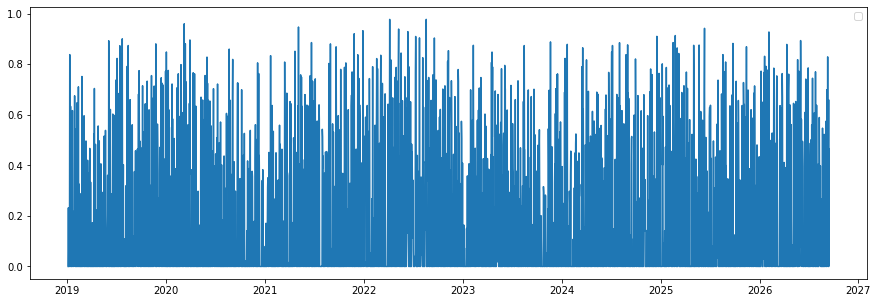

In [34]:
#upper/lower wick ratio

uwr = np.array([(crpdata['high'][i] - max(crpdata['open'][i], crpdata['close'][i]))/(crpdata['high'][i] - crpdata['low'][i]) for i in range(1, len(crpdata))])

lwr = np.array([(max(crpdata['open'][i], crpdata['close'][i]) - crpdata['close'][i])/(crpdata['high'][i] - crpdata['low'][i]) for i in range(1, len(crpdata))])

plt.figure(figsize=(15,5))
plt.plot(npdate, uwr)

plt.figure(figsize=(15,5))
plt.plot(npdate, lwr)

plt.legend()

In [ ]:
#Dist to high/low

window_size = 60

datacrpDt = crpdata[1:]

bgh = len(datacrpDt)-(len(datacrpDt)//window_size)*window_size

data_crop = [datacrpDt['close'][bgh+(window_size*i):bgh+(window_size*(i+1))] for i in range(len(datacrpDt)//window_size)]

dth = np.array([[(data_crop[i].max() - n)/n for n in data_crop[i]] for i in range(len(data_crop))])
dtl = np.array([[(n - data_crop[i].min())/n for n in data_crop[i]] for i in range(len(data_crop))])

for d in dtl:
    plt.figure(figsize=(15,5))
    plt.plot(np.arange(len(d)), d)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


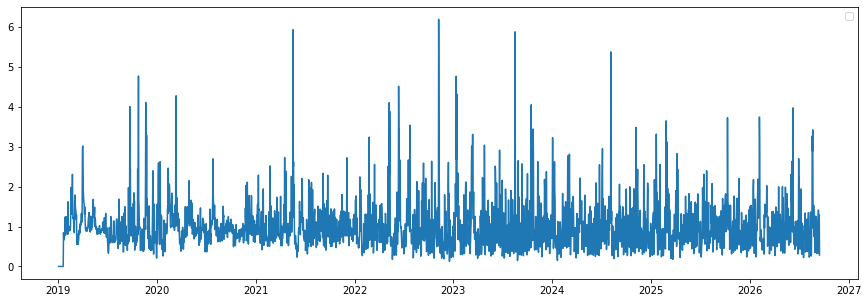

In [114]:
#volume Ratio

volume_window = 20

vlsma = crpdata['volume'].rolling(window=volume_window).mean()
vlr = crpdata['volume']/vlsma
volume_ratio = np.array(vlr[1:].fillna(0))

plt.figure(figsize=(15,5))
plt.plot(npdate, volume_ratio)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


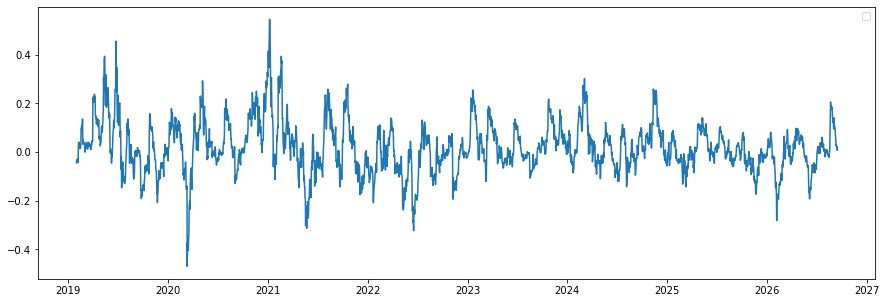

In [119]:
#MA Diff

close_window = 30

clma = crpdata['close'].rolling(window=close_window).mean()
ma_diff = (crpdata['close'] - clma) / clma
ma_diff = np.array(ma_diff[1:])

plt.figure(figsize=(15,5))
plt.plot(npdate, ma_diff)
plt.legend()